In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('Incidenti_Comuni_ProVI_2010-2023.csv', delimiter=';')

In [15]:
df = df[['mese', 'giorno_settimana', 'fascia_oraria', 'comune', 'nome_strada', 'tipo_luogo', 'indirizzo', 'kmt_etm', 'fondo', 'segnaletica', 'meteo']]
df = df.drop(columns=['indirizzo', 'kmt_etm'])

In [16]:
df['incidente'] = 1
df.head()
df_casi_negativi = pd.read_csv('../output/casi_negativi_sintetici.csv')
df_casi_negativi.head()
df_casi_negativi = df_casi_negativi.drop(columns=['lon', 'lat'])
df_casi_negativi.head()

,mese,giorno_settimana,fascia_oraria,comune,nome_strada,tipo_luogo,fondo,segnaletica,meteo,incidente
0,9,Mercoledì,Mattino,SANTORSO,SP 349 Costo,Curva,Bagnato,Temporanea di cantiere,Altro,0
1,4,Domenica,Notte,VILLAVERLA,SP 349 Costo,Galleria illuminata,Asciutto,Assente,Sereno,0
2,1,Giovedì,Mattino,LASTEBASSE,SP 350 Val d'Astico,Dosso,Bagnato,Assente,Neve,0
3,4,Domenica,Mattino,VALLI DEL PASUBIO,SP 046 Pasubio,Intersezione segnalata,Sdrucciolevole,Temporanea di cantiere,Sereno,0
4,1,Lunedì,Sera,VICENZA,SP 046 Pasubio,Dosso,Bagnato,Assente,Sereno,0


In [17]:
df_final = pd.concat([df, df_casi_negativi], ignore_index=True)
df_final.head()
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   mese              2938 non-null   int64
 1   giorno_settimana  2938 non-null   str  
 2   fascia_oraria     2938 non-null   str  
 3   comune            2938 non-null   str  
 4   nome_strada       2938 non-null   str  
 5   tipo_luogo        2938 non-null   str  
 6   fondo             2938 non-null   str  
 7   segnaletica       2879 non-null   str  
 8   meteo             2938 non-null   str  
 9   incidente         2938 non-null   int64
dtypes: int64(2), str(8)
memory usage: 229.7 KB


In [19]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
df_dummy = pd.get_dummies(df_final.drop(columns=['incidente']), drop_first=True)

X = df_dummy
y = df_final['incidente']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)


baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_val_pred = baseline_model.predict_proba(X_val)[:, 1]
print(classification_report(y_val, y_val_pred > 0.5))


              precision    recall  f1-score   support

           0       0.94      0.96      0.95       440
           1       0.87      0.82      0.84       148

    accuracy                           0.92       588
   macro avg       0.90      0.89      0.90       588
weighted avg       0.92      0.92      0.92       588



In [20]:
importances = baseline_model.feature_importances_

# 4. Creiamo un DataFrame per leggerle ed ordinarle comodamente
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df)

                                             Feature  Importance
57                                      meteo_Sereno    0.320926
51                           segnaletica_Orizzontale    0.153922
53                             segnaletica_Verticale    0.085316
52                segnaletica_Temporanea di cantiere    0.085271
56                                     meteo_Pioggia    0.040765
47                                     fondo_Bagnato    0.035770
0                                               mese    0.034444
18                                 comune_LASTEBASSE    0.019843
49                                    fondo_Innevato    0.018406
48                                  fondo_Ghiacciato    0.014924
22                                      comune_ROANA    0.012782
43                 tipo_luogo_Intersezione segnalata    0.012444
7                                fascia_oraria_Notte    0.011628
6                           giorno_settimana_Venerdì    0.011068
45                       

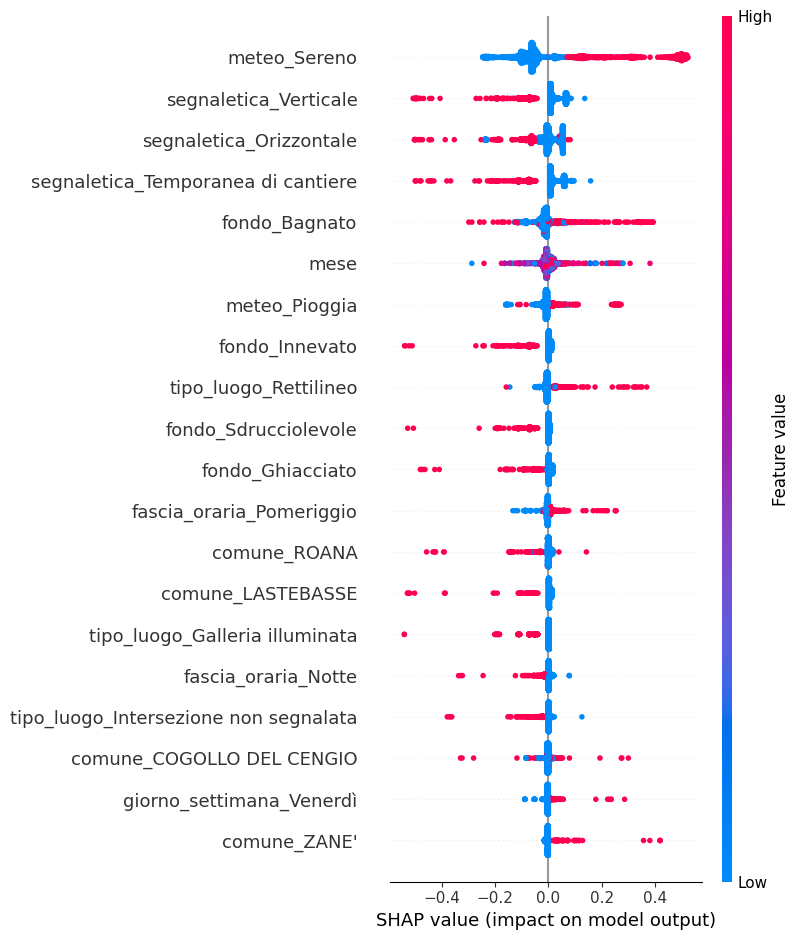

In [26]:
import shap

# Inizializza l'esplicatore specifico per alberi
explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_train)

# Genera un Summary Plot (per problemi di classificazione binaria o una specifica classe)
# Mostra la direzione dell'impatto
shap.summary_plot(shap_values[:, :, 1], X_train)